In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import SpectralClustering
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn import svm
import matplotlib.image as mpimg
from skimage import data, color, io, filters, morphology,transform, exposure, feature
from scipy import ndimage
from skimage.io import imread, imshow
from sklearn import linear_model, datasets
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

##  Clustering

A supermarket collected some data from its customers. The supermarket wants to use this data to better understand its customers. To do this, it wants to apply clustering. This way, customers with a similar profile are grouped together. This allows the supermarket to offer more targeted promotions to each cluster of customers.

You can find the data in the file 'customer.csv'.

In [4]:
dataset = pd.read_csv('Customers.csv')
dataset.head(10)

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### Data analysis

In [5]:
# Remove CustomerID
dataset = dataset.drop('CustomerID', axis=1)
dataset.head(10)

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
5,Female,22,17,76
6,Female,35,18,6
7,Female,23,18,94
8,Male,64,19,3
9,Female,30,19,72


Examine the distribution by gender. What is the ratio of male customers to female customers? Use the seaborn countplot for this.

<Axes: xlabel='Gender', ylabel='count'>

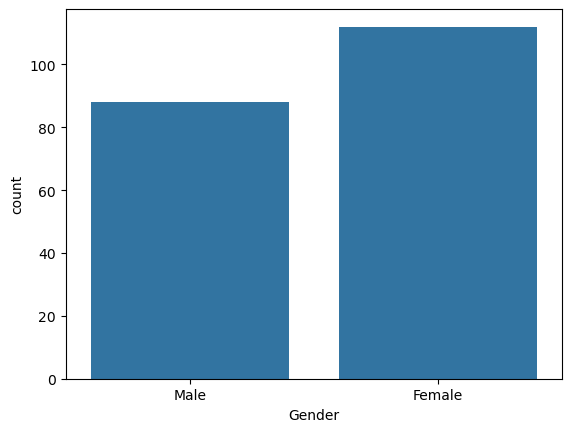

In [ ]:
# Distribution by gender
sns.countplot(x='Gender', data=dataset)

# The gender distribution is balanced.

Determine if women appear to spend more money than men. Visualize this with a boxplot.

<Axes: xlabel='Gender', ylabel='Spending_Score'>

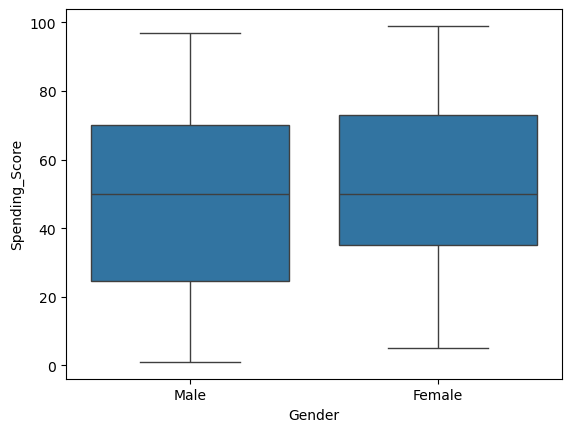

In [ ]:
# Boxplot of spending by gender
sns.boxplot(x='Gender', y='Spending_Score', data=dataset)

# Women tend to spend more money on average than men.

Draw the histograms of Age, Income, and Spending score. You can use the seaborn distplot for this. Are they normally distributed?

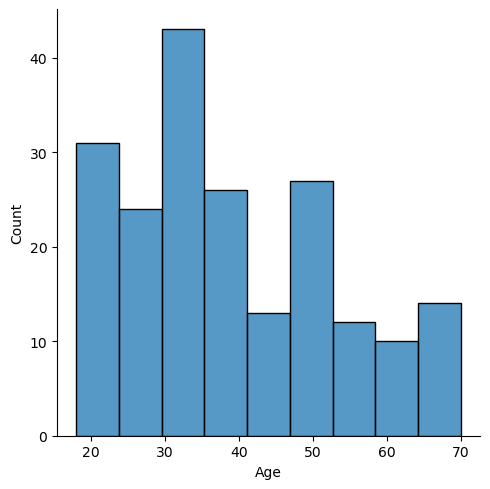

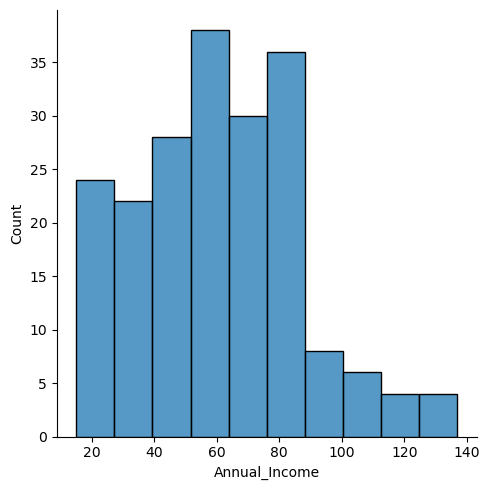

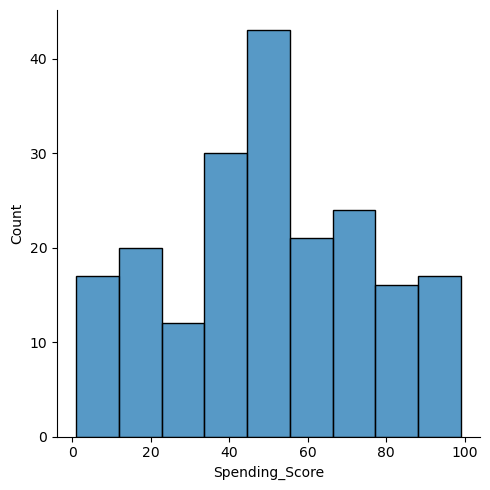

In [ ]:
# Distribution of the Age, Income en Spending_Score
sns.displot(dataset['Age'])
sns.displot(dataset['Annual_Income'])
sns.displot(dataset['Spending_Score'])

# The distributions of Age and Annual_Income are not normally distributed.
# The distribution of Spending_Score is kind of normally distributed.

### Clustering

Time to search for a good clustering of the customers.

In clustering, it's important to first scale the features. Many clustering techniques use a distance function to determine the similarity between different data points. Therefore, it's necessary for all variables to be on the same scale.

Draw a scatterplot between Age and Spending Score.
How many clusters do you think you can find in the scatterplot?
Scale the features Age and Spending Score.
Apply K-means clustering. Choose a K value (number of clusters) based on your estimation. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
Visualize the clusters on the scatterplot.
Now, search for the optimal number of clusters using the elbow method. To do this, calculate the total squared distance of all data points within a cluster to the center of the cluster they belong to. This is automatically calculated during training. You can retrieve this value after training via the inertia_ property. Create a for-loop where you vary K between 1 and 10. For each K value, train the K-means and visualize the clusters. Also, keep track of the inertia_ each time. Then, plot the 'elbow curve' by plotting the inertia_ against K. The point where the bend (elbow) is located is a good indication of the number of clusters to choose.
Repeat the above steps for the scatterplot between Annual Income and Spending Score.



Text(0.5, 1.0, 'Age and Spending Score scatterplot')

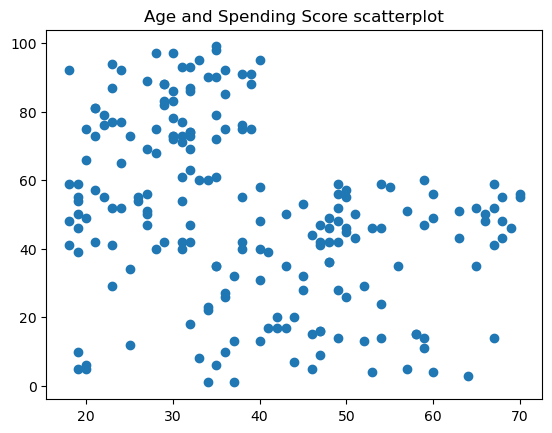

In [16]:
# Clustering Age and Spending_Score
plt.scatter(dataset['Age'], dataset['Spending_Score'])
plt.title("Age and Spending Score scatterplot")

c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[Text(0.5, 1.0, 'Age and Spending Score scatterplot')]

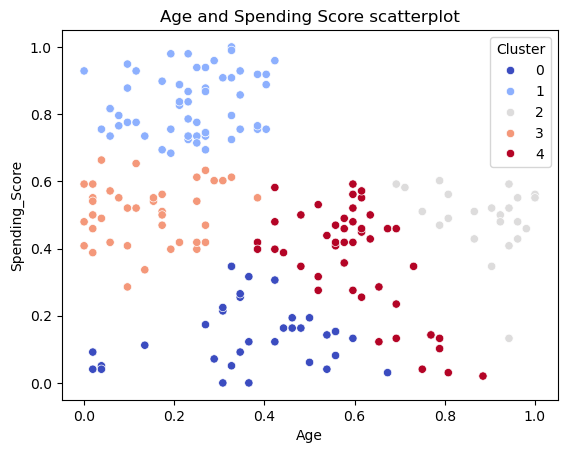

In [ ]:
# Scale Age and Spending_Score and apply K-means clustering
scaler = MinMaxScaler()
dataset[['Age', 'Spending_Score']] = scaler.fit_transform(dataset[['Age', 'Spending_Score']])

kmeans = KMeans(n_clusters=5)
kmeans.fit(dataset[['Age', 'Spending_Score']])
labels = kmeans.labels_
dataset['Cluster'] = labels

sns.scatterplot(x='Age', y='Spending_Score', hue='Cluster', data=dataset, palette='coolwarm').set(title='Age and Spending Score scatterplot')

c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

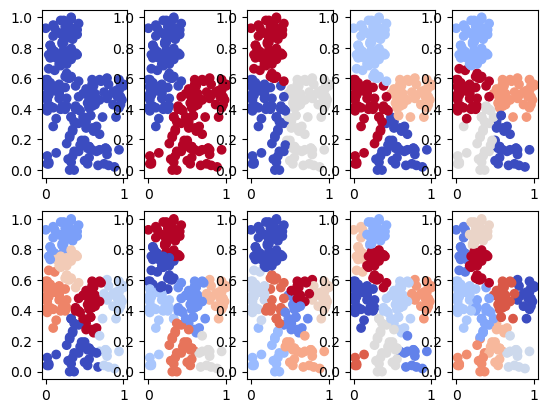

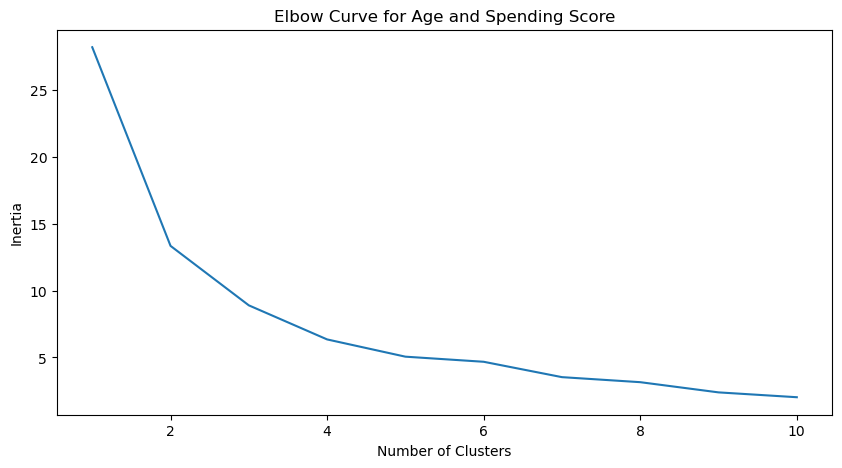

In [40]:
# Search for optimal number of clusters using the elbow method
X = dataset[['Age', 'Spending_Score']]

inertia_values = []

for K in range(1, 11):
    kmeans = KMeans(n_clusters=K)
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)
    inertia_values.append(kmeans.inertia_)
    plt.subplot(2, 5, K)
    plt.scatter(x='Age', y='Spending_Score', c=y_kmeans, cmap='coolwarm', data=dataset)

plt.figure(2, figsize=(10, 5))
plt.plot(range(1, 11), inertia_values)
plt.title('Elbow Curve for Age and Spending Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Text(0.5, 1.0, 'Annual Income and Spending Score scatterplot')

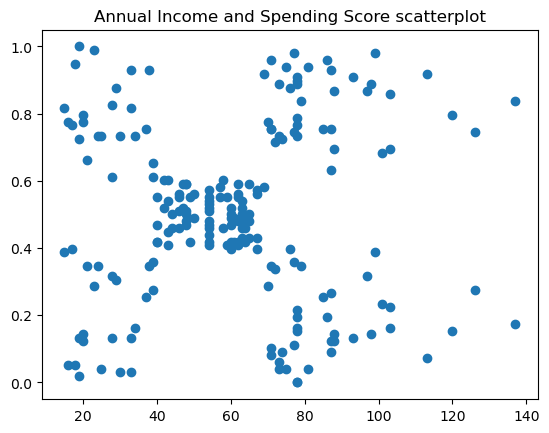

In [35]:
# Clustering Annual_Income and Spending_Score
plt.scatter(dataset['Annual_Income'], dataset['Spending_Score'])
plt.title("Annual Income and Spending Score scatterplot")

c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[Text(0.5, 1.0, 'Annual Income and Spending Score scatterplot')]

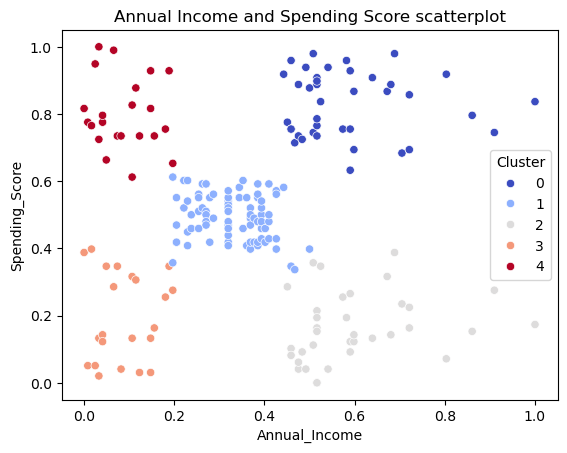

In [36]:
# Scale Annual_Income and apply K-means clustering
# Spending_Score is already scaled in cell above, therefore I only scale Annual_Income
scaler = MinMaxScaler()
dataset[['Annual_Income']] = scaler.fit_transform(dataset[['Annual_Income']])

kmeans = KMeans(n_clusters=5)
kmeans.fit(dataset[['Annual_Income', 'Spending_Score']])
labels = kmeans.labels_
dataset['Cluster'] = labels

sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=dataset, palette='coolwarm').set(title='Annual Income and Spending Score scatterplot')

c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\carll\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

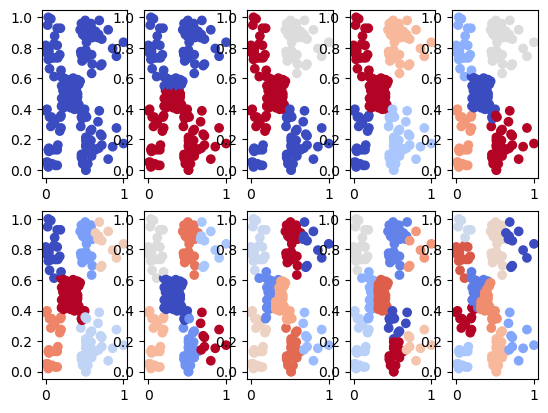

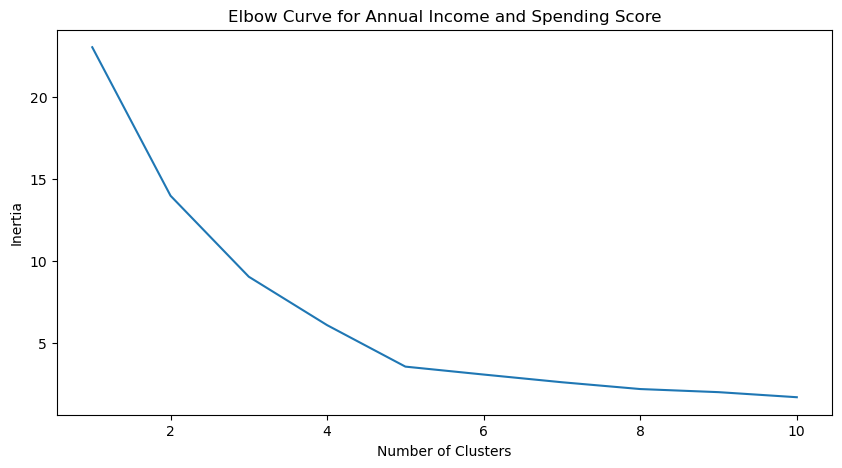

In [39]:
# Search for optimal number of clusters using the elbow method
X = dataset[['Annual_Income', 'Spending_Score']]

inertia_values = []

for K in range(1, 11):
    kmeans = KMeans(n_clusters=K)
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)
    inertia_values.append(kmeans.inertia_)
    plt.subplot(2, 5, K)
    plt.scatter(x='Annual_Income', y='Spending_Score', c=y_kmeans, cmap='coolwarm', data=dataset)

plt.figure(2, figsize=(10, 5))
plt.plot(range(1, 11), inertia_values)
plt.title('Elbow Curve for Annual Income and Spending Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

### Conclusions
The best number of clusters for both **``Age & Spending_Score``** and **``Annual_Income & Spending_Score``** is 5.

By both looking at the subplots and the elbow curve, we can see that the elbow curve stops decreasing at 5 clusters and this can be seen in the subplots as well.

Now try to cluster the scatterplot between Gender and Spending Score. You will notice that there is affinity between the data points. A method suitable for clustering this connected data is spectral clustering. Apply this to Annual Income and Spending Score.
More information about SpectralClustering can be found at https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

In [6]:
# Clustering Gender and Spending Score. First using K-means, then using Spectral Clustering.



Find the clusters using K-means based on Age, Annual Income, and Spending Score. Also, use the elbow method to determine the number of clusters.

After clustering, revert the data back to its original scale. Most scalers have an inverse_transform method that you can use for rescaling.

Plot the scatterplot and clusters in 3D. You are free to choose a library of choice for this.

In how many clusters have you classified the data? Can you describe them? Which ones are interesting for the supermarket to focus on if they want to increase their profit?

In [7]:
# Clustering Age, Annual_Income and Spending_Score + 3D visualization and final interpretation 


##  Face recognition

The goal of this exercise is to perform facial recognition using Eigenfaces. This Eigenfaces technique was one of the first successful attempts to classify faces using computer vision. Nowadays, this method is outdated and far surpassed by techniques based on Convolutional Neural Networks (see deep learning module).
For this exercise, a training and test set of faces is provided. The faces are from the Georgia Tech face database (http://www.anefian.com/research/face_reco.htm) and contain faces of 50 different individuals. Fifteen photos were taken of each person.
The provided photos have already undergone some form of preprocessing, such as face cropping and face rotation.
The person's ID can be extracted from the filename of each photo. For example: person22_15.jpg. Here, it refers to the 15th photo of person 22.

This assignment closely resembles the MNIST_PCA demo.

The steps to achieve successful completion are as follows:

- Read the images. Extract the label of the face from the filename.


- Convert the images to grayscale. This is already done in the available code during image reading.

- Resize all images to the same dimensions. For example, 150x110 (150 rows, 110 columns). This can be done via skimage.transform.resize().
- Transform the training and test sets so that each individual image consists of 1 row. In other words, convert a 2D image into a 1D vector by concatenating all rows of the image.This can be done via np.reshape().
- Perform Principle Component Analysis (PCA). In practice, around 40 Eigenfaces are typically used. This is also the number you can initially use. Later, you will be asked to vary this number.
- Train a classifier (logistic regression, SVM, Random Forest Classifier) on the principle components.
- Test the classifier and evaluate its performance (accuracy, recall, precision). Justify why you would choose a particular classifier.
- Perform hyperparameter tuning and try different numbers of Eigenfaces.






### Computing the principle components

In [5]:
# Reading the training images
training_images = [] # empty list
test_images = [] # empty list
y_train = [] # empty list
y_test = [] # empty list

path = "./Faces/Training_images/"
valid_images = [".jpg",".gif",".png"]

for f in os.listdir(path):
    ext = os.path.splitext(f)[1]
    if ext.lower() not in valid_images:
        continue
    training_images.append(imread(os.path.join(path,f),as_gray=True))
    y_train.append(int(f[6:8]))
   
     
# Reading the test images
path = "./Faces/Test_images/"
valid_images = [".jpg",".gif",".png"]
for f in os.listdir(path):
    ext = os.path.splitext(f)[1]
    if ext.lower() not in valid_images:
        continue
    test_images.append(imread(os.path.join(path,f),as_gray=True))
    y_test.append(int(f[6:8]))
    
print("number of training images: ", len(y_train))
print("number of test images: ", len(y_test))

print("number of unique persons in the training set: ", len(set(y_train)))
print("number of unique persons in the test set: ", len(set(y_test)))

number of training images:  500
number of test images:  250
number of unique persons in the training set:  50
number of unique persons in the test set:  50


In [8]:
# Show a face image included in the training set by using plt.imshow(image,cmap='gray')



In [9]:
# Scaling to 150 rows and 110 columns
# Skimage transform has the resize method
# transform.resize(image,(rows,cols),mode='constant')



In [10]:
# Create a training set and test set. Transforming images to one dimension (1 row of pixels per image).



In [11]:
# Dimensionality reduction: Principle Component Analysis with 40 components


In [6]:
# Visualize the first 10 principle components (the first 10 Eigenfaces)



In [13]:
# Plot the PCA scores of a specific face.
# What is the meaning of these scores?



In [14]:
# What percentage of the total variance is explained by all principle components?



In [15]:
# Generate a combined plot of: the explained variance as a function of the number of principle components.
# Generate a Bar chart of the explained variance of the individual principle components and, on the other hand, the cumulative explained variance.



In [16]:
# Reconstruct a face based on its principle components


### Classification

Train multiple classifiers (logistic regression, SVM, Random Forest Trees, ensembles) for facial recognition. Use the weights obtained through PCA analysis as features. Perform cross-validation to find the optimal hyperparameters.

- Experiment with the number of Eigenfaces used. What happens to the accuracy of the classifiers when you decrease the number (less than 40), and what if you increase it?
- Does the number of Eigenfaces used significantly affect computation time?
- Clearly describe which method you prefer.
- Visualize some misclassified faces.


In [33]:
# Scaling of the eigenfaces



In [17]:
# Classification


In [18]:
# Wrongly classified faces:



See if you can further increase the accuracy using ensemble methods such as boosting.

In [19]:
# Ensemble methods
